# EDA general — Top 5 ligas europeas 2025-26

Exploración a nivel de equipo de las 5 grandes ligas europeas temporada 2025-2026. 
Data pública de fbref.

Estructura:
1. Estilos de juego y diferencias por liga
2. Porteros
3. Identidad de cada liga

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

from viz_theme import (LEAGUE_ORDER, LEAGUE_COLORS, SEQUENTIAL_BLUE, DIVERGING, INK,
                        apply_theme, apply_plotly_theme, league_color,
                        render_with_sidebar, render_plot, league_box_figure)

apply_theme()
apply_plotly_theme()
pd.set_option('display.max_columns', 60)

## Carga y limpieza

Los 5 CSVs son a nivel de equipo, con doble header (categoría + estadístico) y sin columna de liga explícita. Los archivos vienen concatenados en bloques ordenados por liga, así que la columna `liga` se puede asignar por rango de filas.

In [2]:
DATA_DIR = '../data'

RAW_FILES = {
    'ov': 'leagues_overall.csv',
    'sh': 'leagues_shoot.csv',
    'pt': 'leagues_playtime.csv',
    'ms': 'leagues_misc.csv',
    'gk': 'leagues_gk.csv',
}

LEAGUE_BLOCKS = [
    ('Bundesliga', 18),
    ('Serie A', 20),
    ('Ligue 1', 18),
    ('La Liga', 20),
    ('Premier League', 20),
]
liga_col = [liga for liga, n in LEAGUE_BLOCKS for _ in range(n)]


def flatten_columns(raw):
    cols = []
    for top, bot in raw.columns:
        top = '' if str(top).startswith('Unnamed') else str(top).strip()
        bot = str(bot).strip()
        cols.append(f'{top}_{bot}' if top else bot)
    raw.columns = cols
    return raw


frames = {}
for tag, fname in RAW_FILES.items():
    raw = pd.read_csv(f'{DATA_DIR}/{fname}', header=[0, 1])
    raw = flatten_columns(raw)
    assert len(raw) == len(liga_col), f'{fname}: {len(raw)} filas, se esperaban {len(liga_col)}'
    raw['liga'] = liga_col
    stat_cols = [c for c in raw.columns if c not in ('Squad', 'liga')]
    raw = raw.rename(columns={c: f'{tag}_{c}' for c in stat_cols})
    frames[tag] = raw

df = frames['ov']
for tag in ['sh', 'pt', 'ms', 'gk']:
    df = df.merge(frames[tag].drop(columns=['liga']), on='Squad', how='left')

# PKwon/PKcon están vacías, por lo que las eliminaremos 
df = df.drop(columns=['ms_Performance_PKwon', 'ms_Performance_PKcon'])

# tasas por 90' que no vienen precalculadas en misc.csv (solo las que se usan
# en algún gráfico; Crs y Fld se sacaron del loop porque quedaron sin uso)
for col in ['ms_Performance_Fls', 'ms_Performance_Off',
            'ms_Performance_Int', 'ms_Performance_TklW', 'ms_Performance_CrdY']:
    df[col.replace('ms_Performance_', 'p90_')] = df[col] / df['ms_90s']

df['liga'] = pd.Categorical(df['liga'], categories=LEAGUE_ORDER, ordered=True)
cols = ['Squad', 'liga'] + [c for c in df.columns if c not in ('Squad', 'liga')]
df = df[cols]

display(df[df['liga'] == 'Serie A'].head(3))

,Squad,liga,ov_# Pl,ov_Age,ov_Poss,ov_Playing Time_MP,ov_Playing Time_Starts,ov_Playing Time_Min,ov_Playing Time_90s,ov_Performance_Gls,ov_Performance_Ast,ov_Performance_G+A,ov_Performance_G-PK,ov_Performance_PK,ov_Performance_PKatt,ov_Performance_CrdY,ov_Performance_CrdR,ov_Per 90 Minutes_Gls,ov_Per 90 Minutes_Ast,ov_Per 90 Minutes_G+A,ov_Per 90 Minutes_G-PK,ov_Per 90 Minutes_G+A-PK,sh_# Pl,sh_90s,sh_Standard_Gls,sh_Standard_Sh,sh_Standard_SoT,sh_Standard_SoT%,sh_Standard_Sh/90,sh_Standard_SoT/90,...,ms_Performance_Off,ms_Performance_Crs,ms_Performance_Int,ms_Performance_TklW,ms_Performance_OG,gk_# Pl,gk_Playing Time_MP,gk_Playing Time_Starts,gk_Playing Time_Min,gk_Playing Time_90s,gk_Performance_GA,gk_Performance_GA90,gk_Performance_SoTA,gk_Performance_Saves,gk_Performance_Save%,gk_Performance_W,gk_Performance_D,gk_Performance_L,gk_Performance_CS,gk_Performance_CS%,gk_Penalty Kicks_PKatt,gk_Penalty Kicks_PKA,gk_Penalty Kicks_PKsv,gk_Penalty Kicks_PKm,gk_Penalty Kicks_Save%,p90_Fls,p90_Off,p90_Int,p90_TklW,p90_CrdY
18,Atalanta,Serie A,27,26.7,55.2,38,418,3420,38.0,50,33,83,47,3,3,60,2,1.32,0.87,2.18,1.24,2.11,27,38.0,50,563,175,31.1,14.82,4.61,...,73,711,313,361,1,2,38,38,3420,38.0,36,0.95,152,115,76.3,15,14,9,13,34.2,4,2,2,0,50.0,11.842105,1.921053,8.236842,9.500000,1.578947
19,Bologna,Serie A,30,26.5,55.2,38,418,3420,38.0,47,30,77,42,5,7,67,6,1.24,0.79,2.03,1.11,1.89,30,38.0,47,490,144,29.4,12.89,3.79,...,73,671,279,311,1,3,38,38,3415,38.0,49,1.29,141,92,65.2,16,8,14,12,31.6,4,4,0,0,0.0,13.157895,1.921053,7.342105,8.184211,1.763158
20,Cagliari,Serie A,31,24.8,45.6,38,418,3420,38.0,40,30,70,38,2,2,81,2,1.05,0.79,1.84,1.00,1.79,31,38.0,40,415,132,31.8,10.92,3.47,...,61,543,334,359,0,1,38,38,3420,38.0,53,1.39,175,121,69.7,11,10,17,8,21.1,2,2,0,0,0.0,13.789474,1.605263,8.789474,9.447368,2.131579


## 1. Estilos de juego y diferencias por liga

### Perfil de liga

Promedio por liga de 7 métricas de estilo (Goles, G/Sh, CS%, Tackles, Intercepciones, Offsides, Faltas), escaladas contra el máximo entre las 5 ligas (`value / max`). Con esto la separación en cada eje refleja la diferencia **proporcional real** entre ligas —una diferencia chica se ve chica y una grande se ve grande— en vez del min-max o el z-score, que estiran todo a spread completo aunque la diferencia no exista. Las métricas se eligieron por eta² (cuánta de la variación la explica la liga vs. el ruido entre equipos): quedaron fuera Posesión (~50% fija para todas), Tiros y Centros (casi idénticas entre ligas). Cada radar es la "personalidad" de una liga.

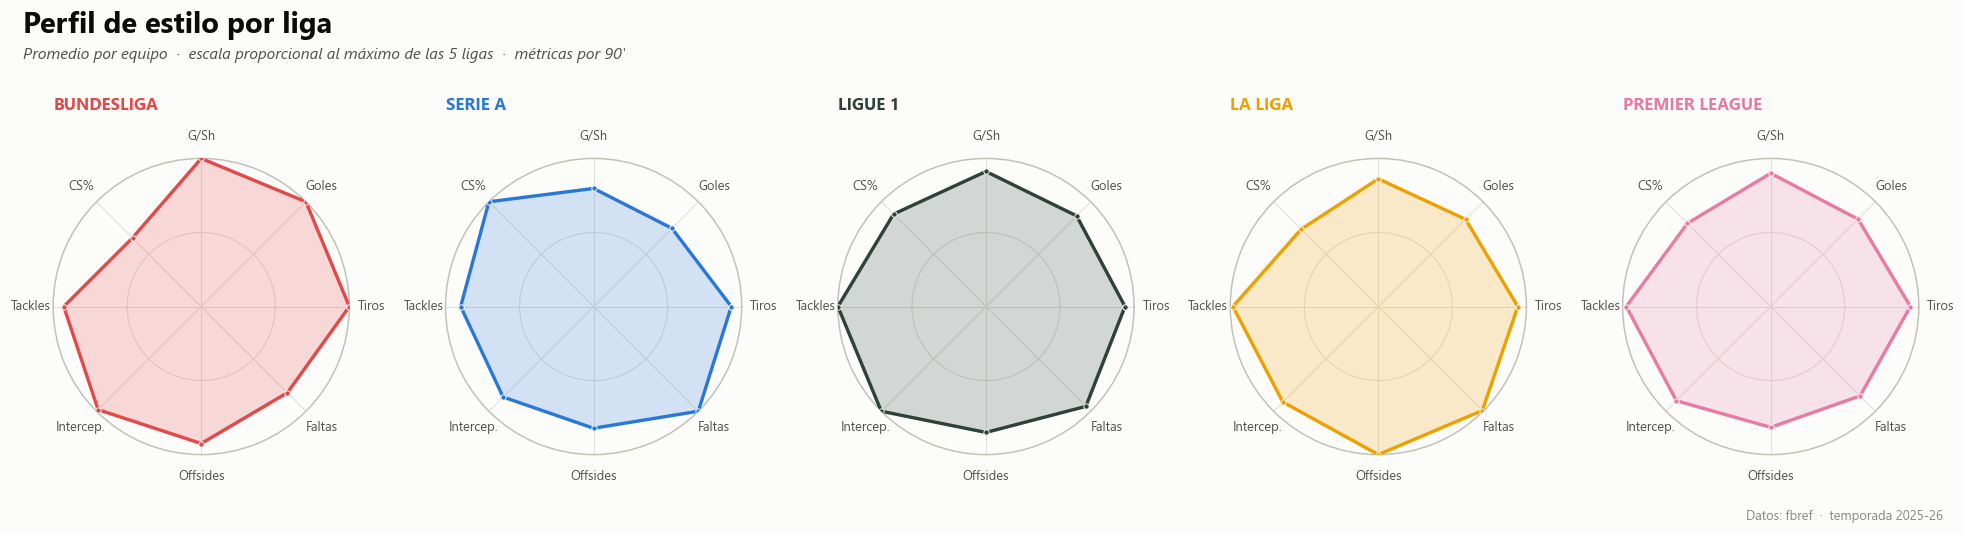

In [3]:
RADAR_METRICS = [
    ('sh_Standard_Sh/90', 'Tiros'),
    ('ov_Per 90 Minutes_Gls', 'Goles'),
    ('sh_Standard_G/Sh', 'G/Sh'),
    ('gk_Performance_CS%', 'CS%'),
    ('p90_TklW', 'Tackles'),
    ('p90_Int', 'Intercep.'),
    ('p90_Off', 'Offsides'),
    ('p90_Fls', 'Faltas'),
]
metric_cols = [c for c, _ in RADAR_METRICS]
labels = [l for _, l in RADAR_METRICS]

league_avg = df.groupby('liga', observed=True)[metric_cols].mean()

# Escala proporcional al máximo (value / max): el 0 del eje es el 0 real de la
# métrica, no la peor liga. La separación en cada eje sigue la diferencia REAL
# entre ligas (una liga con 170 tiros queda pegada a la de 180, no en el polo
# opuesto), a diferencia del min-max o del z-score, que estiran cada eje a
# spread completo aunque la diferencia sea inexistente.
norm = league_avg / league_avg.max()

n = len(labels)
angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(1, 5, figsize=(18, 4.8), subplot_kw=dict(polar=True))
for ax, liga in zip(axes, LEAGUE_ORDER):
    values = norm.loc[liga, metric_cols].tolist()
    values += values[:1]
    color = league_color(liga)
    ax.plot(angles, values, color=color, linewidth=2.2, solid_capstyle='round',
            marker='o', markersize=3.5, markerfacecolor=color,
            markeredgecolor=INK['surface'], markeredgewidth=0.6, zorder=3)
    ax.fill(angles, values, color=color, alpha=0.20, zorder=2)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=8.5, color=INK['secondary'])
    ax.tick_params(axis='x', pad=4)
    ax.set_yticks([0.5])
    ax.set_yticklabels([])
    ax.set_ylim(0, 1)
    ax.set_rlabel_position(0)
    ax.grid(color=INK['grid'], linewidth=0.7)
    ax.spines['polar'].set_color(INK['axis'])
    ax.spines['polar'].set_linewidth(1.0)
    ax.set_title(liga.upper(), color=color, fontsize=11, fontweight='bold', pad=13)

# Título/subtítulo alineados a la izquierda del canvas (x=0.015), igual que el
# resto de los gráficos del notebook — antes usaban fracciones sueltas
# (0.42/0.35) pensadas para centrar sobre los 5 subplots, pero eso solo
# cuadraba bien al ancho de figura exacto de ese momento.
fig.text(0.015, 0.99, 'Perfil de estilo por liga', ha='left', va='top',
         fontsize=19, fontweight='bold', color=INK['primary'])
fig.text(0.015, 0.92, "Promedio por equipo  ·  escala proporcional al máximo de las 5 ligas  ·  métricas por 90'",
         ha='left', va='top', fontsize=10.5, style='italic', color=INK['secondary'])
fig.text(0.985, 0.02, 'Datos: fbref  ·  temporada 2025-26',
         ha='right', va='bottom', fontsize=8.5, color=INK['muted'])
plt.tight_layout(rect=[0, 0.03, 1, 0.83])
plt.show()

### Perfil de liga, sobrepuesto

Las mismas formas del radar anterior, ahora en un solo gráfico para comparar directamente dónde se separa cada liga. La tabla de la derecha cuantifica esa separación por eje: **1 − (mín ÷ máx)** de las 5 ligas en cada métrica, en % y ordenada de mayor a menor separación. CS% es donde más se diferencian (34%); Tiros es donde casi no se distinguen (7%) — un insight en sí mismo: las 5 ligas rondan un volumen de tiro por partido muy similar, aunque todo lo demás (definición, portería, físico) varíe bastante.

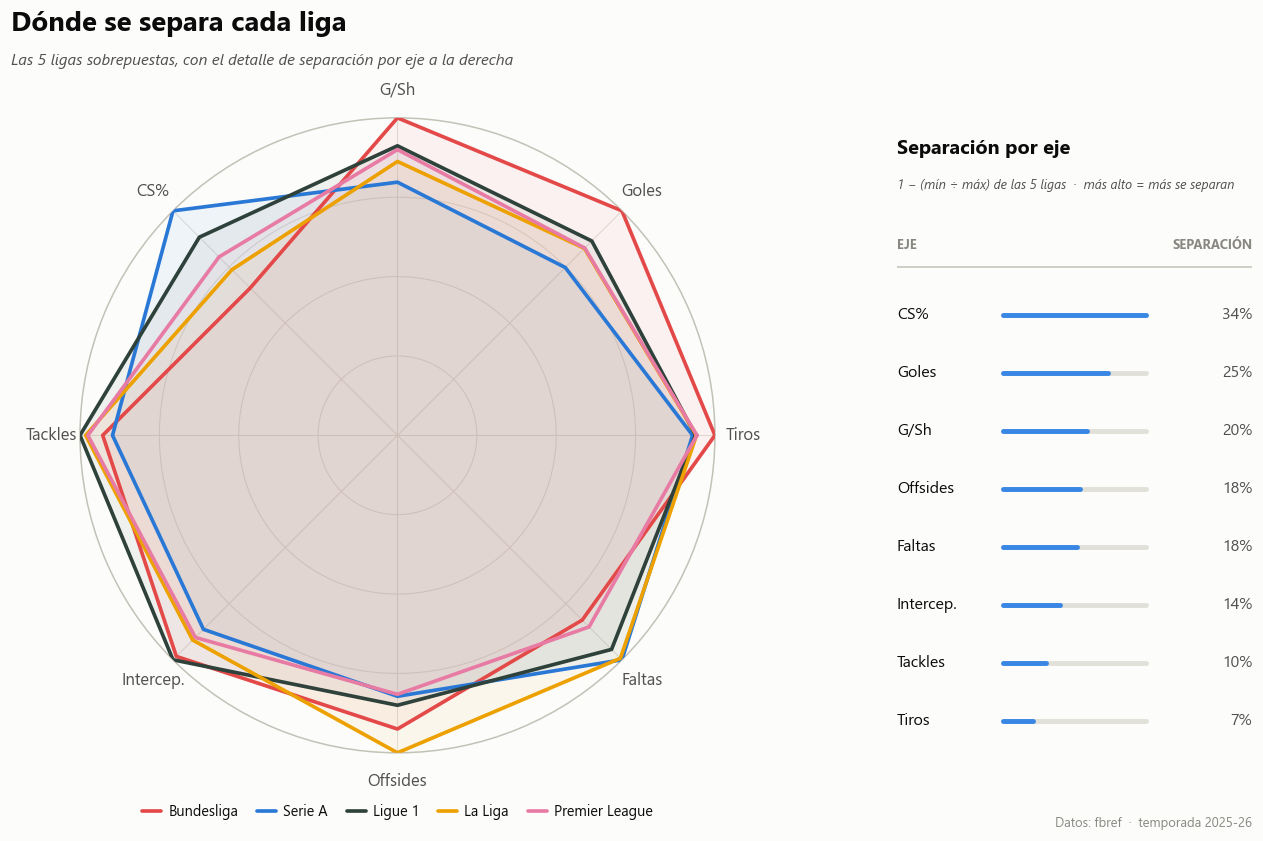

In [4]:
fig = plt.figure(figsize=(12.2, 7.8))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 0.46], wspace=0.20,
                      left=0.045, right=0.97, top=0.85, bottom=0.11)
ax = fig.add_subplot(gs[0], polar=True)
tax = fig.add_subplot(gs[1])

# --- radar sobrepuesto ---
for liga in LEAGUE_ORDER:
    values = norm.loc[liga, metric_cols].tolist()
    values += values[:1]
    color = league_color(liga)
    ax.plot(angles, values, color=color, linewidth=2.4, solid_capstyle='round', label=liga, zorder=3)
    ax.fill(angles, values, color=color, alpha=0.06, zorder=2)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=11, color=INK['secondary'])
ax.tick_params(axis='x', pad=8)
ax.set_yticks([0.25, 0.5, 0.75])
ax.set_yticklabels([])
ax.set_ylim(0, 1)
ax.set_rlabel_position(0)
ax.grid(color=INK['grid'], linewidth=0.7)
ax.spines['polar'].set_color(INK['axis'])
ax.spines['polar'].set_linewidth(1.0)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.06), ncol=5, fontsize=9.5,
          columnspacing=1.3, handletextpad=0.5, handlelength=1.3)

# --- tabla a la derecha: % de separación entre ligas por eje, mayor primero ---
# 1 - (mín/máx): mayor = las ligas se separan más en ese eje. Se ordena
# descendente para que el eje más interesante (CS%, 34%) tenga la barra más
# larga y quede arriba; el peso visual queda alineado con la información
# (antes, con el ratio crudo ordenado ascendente, la barra más larga era la
# del eje MENOS interesante — Tiros — que es justo lo opuesto a lo que
# conviene destacar).
sep_pct = ((1 - league_avg.min() / league_avg.max()) * 100).reindex(metric_cols).sort_values(ascending=False)
col2label = dict(RADAR_METRICS)

tax.set_xlim(0, 1); tax.set_ylim(0, 1); tax.axis('off')
tax.text(0.0, 0.965, 'Separación por eje', transform=tax.transAxes, ha='left', va='top',
         fontsize=13, fontweight='bold', color=INK['primary'])
tax.text(0.0, 0.905, '1 − (mín ÷ máx) de las 5 ligas  ·  más alto = más se separan', transform=tax.transAxes,
         ha='left', va='top', fontsize=8.5, style='italic', color=INK['secondary'])
y0 = 0.80
tax.text(0.0, y0, 'EJE', ha='left', va='center', fontsize=8.5, fontweight='bold', color=INK['muted'])
tax.text(1.0, y0, 'SEPARACIÓN', ha='right', va='center', fontsize=8.5, fontweight='bold', color=INK['muted'])
tax.plot([0, 1], [y0 - 0.035, y0 - 0.035], color=INK['axis'], lw=1.0)

rows = list(sep_pct.items())
ys = np.linspace(y0 - 0.11, 0.05, len(rows))
bx0, bx1 = 0.30, 0.70
maxv = sep_pct.max()
for (col, val), y in zip(rows, ys):
    tax.text(0.0, y, col2label.get(col, col), ha='left', va='center', fontsize=10.5, color=INK['primary'])
    tax.plot([bx0, bx1], [y, y], color=INK['grid'], lw=3.2, solid_capstyle='round', zorder=1)
    tax.plot([bx0, bx0 + (bx1 - bx0) * (val / maxv)], [y, y], color=SEQUENTIAL_BLUE[3], lw=3.2,
             solid_capstyle='round', zorder=2)
    tax.text(1.0, y, f'{val:.0f}%', ha='right', va='center', fontsize=10.5, color=INK['secondary'])

fig.text(0.045, 0.975, 'Dónde se separa cada liga', ha='left', va='top',
         fontsize=18, fontweight='bold', color=INK['primary'])
fig.text(0.045, 0.925, 'Las 5 ligas sobrepuestas, con el detalle de separación por eje a la derecha',
         ha='left', va='top', fontsize=10.5, style='italic', color=INK['secondary'])
fig.text(0.97, 0.02, 'Datos: fbref  ·  temporada 2025-26', ha='right', va='bottom',
         fontsize=8.5, color=INK['muted'])
plt.show()

### Eficiencia de definición: ¿quién define mejor?

G/Sh (goles por tiro) y G/SoT (goles por tiro a puerta) están relacionadas por construcción — `G/Sh = SoT% × G/SoT` — así que graficarlas una contra otra da una nube casi 1-D (r=0.88, mayormente una diagonal). El par que sí separa dos habilidades independientes (r=0.28) es **SoT% vs. G/SoT**: precisión (llegar a puerta) vs. definición (marcar una vez ahí).

Gráfico interactivo (Plotly): hover sobre un punto para ver el equipo. En la barra lateral de la derecha, un buscador de club con autocompletado (escribe y aparecen las coincidencias) y un filtro por liga.

In [5]:
x_col, y_col = 'sh_Standard_SoT%', 'sh_Standard_G/SoT'
x_mean, y_mean = df[x_col].mean(), df[y_col].mean()

scatter_data = [(liga, df[df['liga'] == liga]) for liga in LEAGUE_ORDER]

fig = go.Figure()
for liga, sub in scatter_data:
    fig.add_trace(go.Scatter(
        x=sub[x_col], y=sub[y_col], mode='markers', name=liga,
        marker=dict(color=league_color(liga), size=[11] * len(sub), opacity=0.88,
                    line=dict(color=INK['surface'], width=1)),
        customdata=sub['Squad'],
        hovertemplate=f'<b>%{{customdata}}</b><br>{liga}<br>SoT%%: %{{x:.1f}}%<br>G/SoT: %{{y:.2f}}<extra></extra>',
    ))

fig.add_vline(x=x_mean, line=dict(color=INK['axis'], width=1, dash='dash'))
fig.add_hline(y=y_mean, line=dict(color=INK['axis'], width=1, dash='dash'))

# anotaciones fijas de cuadrante: se guardan en una lista para pasárselas a
# render_with_sidebar como base_annotations — así el buscador de club las
# preserva en vez de reemplazarlas por la etiqueta del club elegido.
quadrant_annotations = [
    dict(x=x_mean + 0.4, y=df[y_col].max() + 0.005, text='certeros y letales',
         showarrow=False, font=dict(size=10.5, color=INK['muted']), xanchor='left', yanchor='bottom'),
    dict(x=x_mean - 0.4, y=df[y_col].max() + 0.005, text='poco a puerta, pero letales',
         showarrow=False, font=dict(size=10.5, color=INK['muted']), xanchor='right', yanchor='bottom'),
    dict(x=x_mean + 0.4, y=df[y_col].min() - 0.01, text='mucho a puerta, poca pegada',
         showarrow=False, font=dict(size=10.5, color=INK['muted']), xanchor='left', yanchor='top'),
    dict(x=x_mean - 0.4, y=df[y_col].min() - 0.01, text='ni certeros ni letales',
         showarrow=False, font=dict(size=10.5, color=INK['muted']), xanchor='right', yanchor='top'),
]

fig.update_layout(
    title=dict(text='Eficiencia de definición',
               subtitle=dict(text='Precisión (llegar a puerta) vs. definición (marcar una vez ahí) · '
                                   'pasa el mouse sobre un punto para ver el equipo')),
    xaxis_title='Precisión — % de tiros que van a puerta (SoT%)',
    yaxis_title='Definición — goles por tiro a puerta (G/SoT)',
    annotations=quadrant_annotations,
)
render_with_sidebar(fig, scatter_data, x_col, y_col, base_annotations=quadrant_annotations)

## 2. Porteros

### Ranking de porterías

Índice compuesto: `Save% − GA90` (ambos estandarizados). Originalmente incluía también CS%, pero CS% y GA90 correlacionan −0.84 entre sí (casi la misma señal contada dos veces, porque ambas dependen directamente de cuántos goles recibe el equipo), así que sumarlas no triangulaba nada — inflaba el peso de esa señal en vez de agregar una independiente. Se dejó Save% (tasa de atajadas sobre tiros enfrentados) + GA90 (goles recibidos por partido), que sí capturan cosas distintas.

Ojo con la lectura: GA90 depende tanto de la defensa del equipo como del arquero — uno detrás de una defensa sólida va a tener buenos números sin necesariamente atajar mejor. El siguiente gráfico (SoTA vs. Save%) separa mejor la exigencia real del arquero de su tasa de acierto.

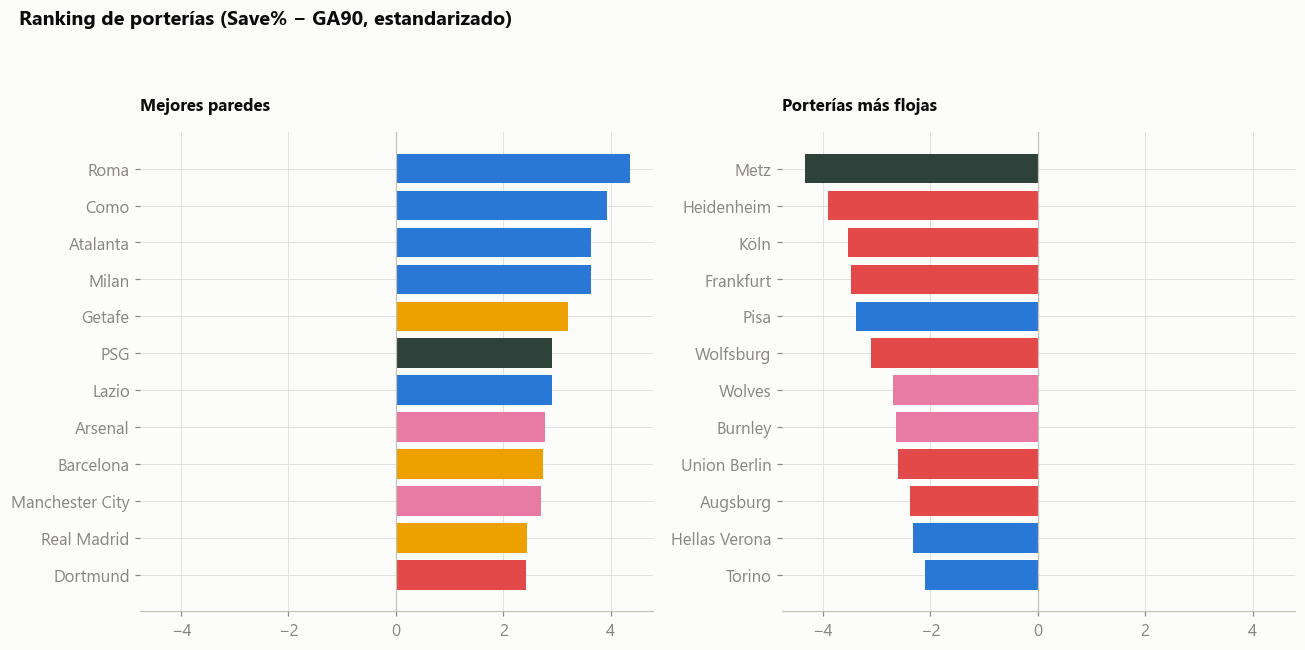

In [6]:
def zscore(s):
    return (s - s.mean()) / s.std()


df['gk_score'] = zscore(df['gk_Performance_Save%']) - zscore(df['gk_Performance_GA90'])
ranked = df.sort_values('gk_score', ascending=False)
top12 = ranked.head(12)
bot12 = ranked.tail(12).sort_values('gk_score')

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True)
for ax, sub, title in zip(axes, [top12, bot12], ['Mejores paredes', 'Porterías más flojas']):
    colors = [league_color(l) for l in sub['liga']]
    ax.barh(sub['Squad'], sub['gk_score'], color=colors)
    ax.invert_yaxis()
    ax.set_title(title, fontsize=11)
    ax.axvline(0, color=INK['axis'], linewidth=0.8)

fig.suptitle('Ranking de porterías (Save% − GA90, estandarizado)',
             x=0.02, ha='left', fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

### Portería vs. resultado del equipo

Puntos por partido (calculados desde el propio récord W/D/L del portero) frente a % de porterías a cero. Interactivo: hover para identificar equipo; buscador de club y filtro por liga en la barra lateral.

In [7]:
df['gk_ppm'] = (df['gk_Performance_W'] * 3 + df['gk_Performance_D']) / df['gk_Playing Time_MP']

x_col3, y_col3 = 'gk_Performance_CS%', 'gk_ppm'
scatter_data3 = [(liga, df[df['liga'] == liga]) for liga in LEAGUE_ORDER]

fig = go.Figure()
for liga, sub in scatter_data3:
    fig.add_trace(go.Scatter(
        x=sub[x_col3], y=sub[y_col3], mode='markers', name=liga,
        marker=dict(color=league_color(liga), size=[11] * len(sub), opacity=0.88,
                    line=dict(color=INK['surface'], width=1)),
        customdata=sub['Squad'],
        hovertemplate=f'<b>%{{customdata}}</b><br>{liga}<br>CS%%: %{{x:.1f}}%<br>Puntos/partido: %{{y:.2f}}<extra></extra>',
    ))

fig.update_layout(
    title=dict(text='¿Cuánto pesa la portería en el resultado?',
               subtitle=dict(text='Porterías a cero vs. puntos por partido · pasa el mouse sobre un punto para ver el equipo')),
    xaxis_title='Porterías a cero (%)', yaxis_title='Puntos por partido',
)
render_with_sidebar(fig, scatter_data3, x_col3, y_col3)

### Exigencia vs. rendimiento: SoTA vs. Save%

`SoTA` (tiros a puerta enfrentados en la temporada) mide cuánto trabajo tuvo el arquero — no se había usado hasta ahora. Cruzado con `Save%` (tasa de atajadas) separa la exigencia real de la tasa de acierto, en vez de mezclarlas como hacían GA90/CS% (confundidas con la defensa del equipo). Mismo criterio que en Eficiencia de definición: no juntar dos cosas que dependen una de la otra. Interactivo: hover para identificar equipo; buscador de club y filtro por liga en la barra lateral.

In [8]:
x_col4, y_col4 = 'gk_Performance_SoTA', 'gk_Performance_Save%'
x_mean4, y_mean4 = df[x_col4].mean(), df[y_col4].mean()
scatter_data4 = [(liga, df[df['liga'] == liga]) for liga in LEAGUE_ORDER]

fig = go.Figure()
for liga, sub in scatter_data4:
    fig.add_trace(go.Scatter(
        x=sub[x_col4], y=sub[y_col4], mode='markers', name=liga,
        marker=dict(color=league_color(liga), size=[11] * len(sub), opacity=0.88,
                    line=dict(color=INK['surface'], width=1)),
        customdata=sub['Squad'],
        hovertemplate=f'<b>%{{customdata}}</b><br>{liga}<br>SoTA: %{{x}}<br>Save%%: %{{y:.1f}}%<extra></extra>',
    ))

fig.add_vline(x=x_mean4, line=dict(color=INK['axis'], width=1, dash='dash'))
fig.add_hline(y=y_mean4, line=dict(color=INK['axis'], width=1, dash='dash'))

quadrant_annotations4 = [
    dict(x=x_mean4 + 3, y=df[y_col4].max() + 0.3, text='muy exigido y rinde',
         showarrow=False, font=dict(size=10.5, color=INK['muted']), xanchor='left', yanchor='bottom'),
    dict(x=x_mean4 - 3, y=df[y_col4].max() + 0.3, text='poco exigido y rinde',
         showarrow=False, font=dict(size=10.5, color=INK['muted']), xanchor='right', yanchor='bottom'),
    dict(x=x_mean4 + 3, y=df[y_col4].min() - 0.6, text='muy exigido, le cuesta',
         showarrow=False, font=dict(size=10.5, color=INK['muted']), xanchor='left', yanchor='top'),
    dict(x=x_mean4 - 3, y=df[y_col4].min() - 0.6, text='poco exigido y rinde poco',
         showarrow=False, font=dict(size=10.5, color=INK['muted']), xanchor='right', yanchor='top'),
]

fig.update_layout(
    title=dict(text='Exigencia vs. rendimiento',
               subtitle=dict(text='Tiros a puerta enfrentados vs. tasa de atajadas · '
                                   'pasa el mouse sobre un punto para ver el equipo')),
    xaxis_title='Tiros a puerta enfrentados en la temporada (SoTA)',
    yaxis_title='Tasa de atajadas (Save%)',
    annotations=quadrant_annotations4,
)
render_with_sidebar(fig, scatter_data4, x_col4, y_col4, base_annotations=quadrant_annotations4)

## 3. Identidad de cada liga

Hasta acá todo fue "cómo juega un equipo dentro de su liga". Esta sección cambia de nivel: son propiedades de **la liga como sistema**, no de un equipo puntual. Los 3 gráficos comparten el mismo formato — un box plot con los 20 (o 18) equipos superpuestos como puntos, para ver tanto el resumen como la evidencia real detrás — y usan columnas de los CSV que no se habían tocado hasta ahora.

### Paridad competitiva

`Team Success_PPM` (puntos por partido) no se había usado a nivel de liga todavía. El número arriba de cada caja es el coeficiente de variación (desvío / media, en %) de los 20 equipos de esa liga: más alto significa que la liga está más repartida entre "un equipo arriba y el resto" y menos alto significa que la competencia es más pareja de punta a punta.

In [9]:
fig = league_box_figure(df, 'pt_Team Success_PPM', 'Puntos por partido', hover_fmt='.2f', annotate_cv=True)
fig.update_layout(
    title=dict(text='Paridad competitiva',
               subtitle=dict(text='Puntos por partido de cada equipo, agrupados por liga · % = coeficiente de variación')),
    yaxis_title='Puntos por partido', xaxis_title=None,
)
render_plot(fig)

### Edad de plantilla

`Age` tampoco se había usado. Diferencia moderada pero real entre ligas (eta² = 0.14).

In [10]:
fig = league_box_figure(df, 'ov_Age', 'Edad', hover_fmt='.1f')
fig.update_layout(
    title=dict(text='Edad de plantilla',
               subtitle=dict(text='Edad promedio de cada equipo, agrupados por liga')),
    yaxis_title='Edad promedio', xaxis_title=None,
)
render_plot(fig)

### Disciplina: tarjetas amarillas

`p90_CrdY` (amarillas por 90 minutos, derivada de `misc.csv`). Diferencia real (eta² = 0.15), y no repartida parejo entre las 5: una liga se despega claramente del resto.

In [11]:
fig = league_box_figure(df, 'p90_CrdY', 'Amarillas/90', hover_fmt='.2f')
fig.update_layout(
    title=dict(text='Disciplina: tarjetas amarillas',
               subtitle=dict(text='Amarillas por 90 minutos de cada equipo, agrupados por liga')),
    yaxis_title='Amarillas por 90', xaxis_title=None,
)
render_plot(fig)